# Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

In [2]:
# Features
X_train = pd.read_csv("../../../data/processed/splits/X_train.csv",
                      parse_dates=["Date"], index_col="Date")
X_val   = pd.read_csv("../../../data/processed/splits/X_val.csv",
                      parse_dates=["Date"], index_col="Date")
X_test  = pd.read_csv("../../../data/processed/splits/X_test.csv",
                      parse_dates=["Date"], index_col="Date")

# Classification targets
y_train = pd.read_csv("../../../data/processed/splits/y_train_clf.csv",
                      parse_dates=["Date"], index_col="Date").squeeze()
y_val   = pd.read_csv("../../../data/processed/splits/y_val_clf.csv",
                      parse_dates=["Date"], index_col="Date").squeeze()
y_test  = pd.read_csv("../../../data/processed/splits/y_test_clf.csv",
                      parse_dates=["Date"], index_col="Date").squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

X_train : (1479, 69)
X_val   : (501, 69)
X_test  : (563, 69)


# Training Model

In [3]:
def evaluate_classifier(name, model, X, y, split_label="Validation", plot=True):
    y_pred = model.predict(X)

    acc     = accuracy_score(y, y_pred)
    f1_mac  = f1_score(y, y_pred, average='macro')
    f1_down = f1_score(y, y_pred, average=None, labels=[-1])[0]
    f1_up   = f1_score(y, y_pred, average=None, labels=[1])[0]

    print(f"  {name}  [{split_label}]")
    print(classification_report(y, y_pred,
          target_names=['Down(-1)', 'Side(0)', 'Up(1)']))

    if plot:
        cm   = confusion_matrix(y, y_pred, labels=[-1, 0, 1])
        disp = ConfusionMatrixDisplay(cm, display_labels=['Down', 'Side', 'Up'])
        disp.plot(cmap='Blues')
        plt.title(f'Confusion Matrix — {name} [{split_label}]')
        plt.tight_layout()
        plt.show()

    return {
        'Model': name, 'Split': split_label,
        'Accuracy': round(acc, 4),
        'F1 Macro': round(f1_mac, 4),
        'F1 Down':  round(f1_down, 4),
        'F1 Up':    round(f1_up, 4),
    }

In [13]:
rf_clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=17,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_clf.fit(X_train, y_train)
print("Random Forest Classifier trained")

Random Forest Classifier trained


# Evaluation


TRAIN METRICS (Overfitting check)
  RF Classifier (Baseline)  [Train]
              precision    recall  f1-score   support

    Down(-1)       0.97      0.99      0.98       375
     Side(0)       0.98      0.96      0.97       649
       Up(1)       0.96      0.98      0.97       455

    accuracy                           0.97      1479
   macro avg       0.97      0.98      0.97      1479
weighted avg       0.97      0.97      0.97      1479


VALIDATION EVALUATION
  RF Classifier (Baseline)  [Validation]
              precision    recall  f1-score   support

    Down(-1)       0.22      0.14      0.17       143
     Side(0)       0.40      0.71      0.51       203
       Up(1)       0.33      0.10      0.15       155

    accuracy                           0.36       501
   macro avg       0.32      0.32      0.28       501
weighted avg       0.33      0.36      0.30       501



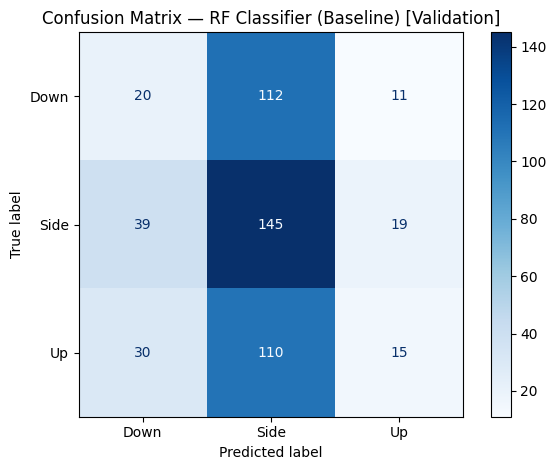


TEST SET EVALUATION
  RF Classifier (Baseline)  [Test]
              precision    recall  f1-score   support

    Down(-1)       0.28      0.17      0.21       120
     Side(0)       0.41      0.86      0.55       227
       Up(1)       0.78      0.03      0.06       216

    accuracy                           0.40       563
   macro avg       0.49      0.35      0.27       563
weighted avg       0.52      0.40      0.29       563



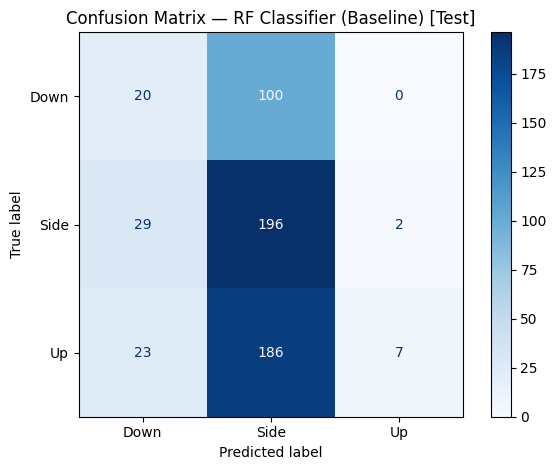

In [5]:
# Train Metrics (Overfitting check)
print("\nTRAIN METRICS (Overfitting check)")
res_train_base = evaluate_classifier(
    "RF Classifier (Baseline)", rf_clf, X_train, y_train,
    split_label="Train", plot=False
)

# Validation Evaluation
print("\nVALIDATION EVALUATION")
res_val_base = evaluate_classifier(
    "RF Classifier (Baseline)", rf_clf, X_val, y_val,
    split_label="Validation"
)

# Test Set Evaluation
print("\nTEST SET EVALUATION")
res_test_base = evaluate_classifier(
    "RF Classifier (Baseline)", rf_clf, X_test, y_test,
    split_label="Test"
)

# Hyperparameter Tuning

In [6]:
# Combine train + val for tuning (time-ordered, no shuffle)
X_tune = pd.concat([X_train, X_val])
y_tune = pd.concat([y_train, y_val])

tscv = TimeSeriesSplit(n_splits=5)

param_dist_clf = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [5, 8, 10, 15, None],
    'min_samples_leaf':  [5, 10, 20],
    'min_samples_split': [10, 20, 40],
    'max_features':      ['sqrt', 'log2'],
}

rf_clf_search = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    param_distributions=param_dist_clf,
    n_iter=30,
    cv=tscv,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rf_clf_search.fit(X_tune, y_tune)

print(f"\nBest params : {rf_clf_search.best_params_}")
print(f"Best F1 Macro (CV): {rf_clf_search.best_score_:.4f}")

best_rf_clf = rf_clf_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params : {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 8}
Best F1 Macro (CV): 0.3409



>>> TRAIN METRICS — Tuned (Overfitting check)
  RF Classifier (Tuned)  [Train]
              precision    recall  f1-score   support

    Down(-1)       0.89      0.90      0.89       375
     Side(0)       0.92      0.89      0.90       649
       Up(1)       0.88      0.92      0.90       455

    accuracy                           0.90      1479
   macro avg       0.90      0.90      0.90      1479
weighted avg       0.90      0.90      0.90      1479


>>> VALIDATION EVALUATION — Tuned
  RF Classifier (Tuned)  [Validation]
              precision    recall  f1-score   support

    Down(-1)       0.94      0.99      0.96       143
     Side(0)       0.97      0.93      0.95       203
       Up(1)       0.94      0.95      0.94       155

    accuracy                           0.95       501
   macro avg       0.95      0.95      0.95       501
weighted avg       0.95      0.95      0.95       501



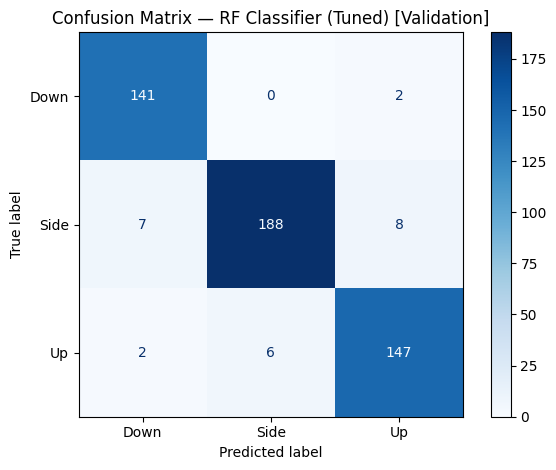


>>> TEST SET EVALUATION — Tuned
  RF Classifier (Tuned)  [Test]
              precision    recall  f1-score   support

    Down(-1)       0.20      0.27      0.23       120
     Side(0)       0.41      0.56      0.47       227
       Up(1)       0.44      0.19      0.26       216

    accuracy                           0.36       563
   macro avg       0.35      0.34      0.32       563
weighted avg       0.38      0.36      0.34       563



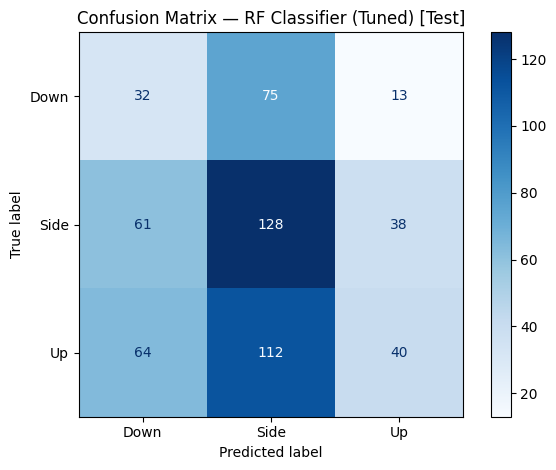

In [7]:
# ──  Tuned: TRAIN / VALIDATION / TEST
print("\n>>> TRAIN METRICS — Tuned (Overfitting check)")
res_train_tuned = evaluate_classifier(
    "RF Classifier (Tuned)", best_rf_clf, X_train, y_train,
    split_label="Train", plot=False
)

print("\n>>> VALIDATION EVALUATION — Tuned")
res_val_tuned = evaluate_classifier(
    "RF Classifier (Tuned)", best_rf_clf, X_val, y_val,
    split_label="Validation"
)

print("\n>>> TEST SET EVALUATION — Tuned")
res_test_tuned = evaluate_classifier(
    "RF Classifier (Tuned)", best_rf_clf, X_test, y_test,
    split_label="Test"
)

# Summary

In [8]:
all_results = pd.DataFrame([
    res_train_base, res_val_base, res_test_base,
    res_train_tuned, res_val_tuned, res_test_tuned,
])

print("\n=== Classification Summary ===")
print(all_results.to_string(index=False))


=== Classification Summary ===
                   Model      Split  Accuracy  F1 Macro  F1 Down  F1 Up
RF Classifier (Baseline)      Train    0.9730    0.9737   0.9802 0.9706
RF Classifier (Baseline) Validation    0.3593    0.2771   0.1724 0.1500
RF Classifier (Baseline)       Test    0.3961    0.2745   0.2083 0.0622
   RF Classifier (Tuned)      Train    0.8986    0.8979   0.8948 0.8968
   RF Classifier (Tuned) Validation    0.9501    0.9506   0.9625 0.9423
   RF Classifier (Tuned)       Test    0.3552    0.3213   0.2310 0.2606


# Feature Important


>>> FEATURE IMPORTANCE — Baseline


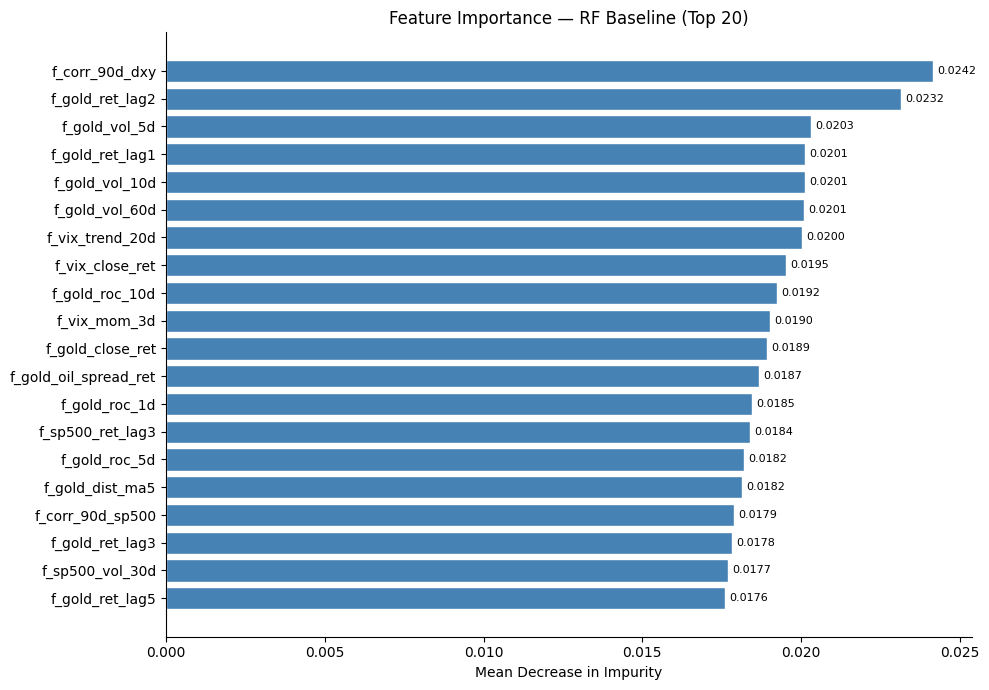


>>> FEATURE IMPORTANCE — Tuned


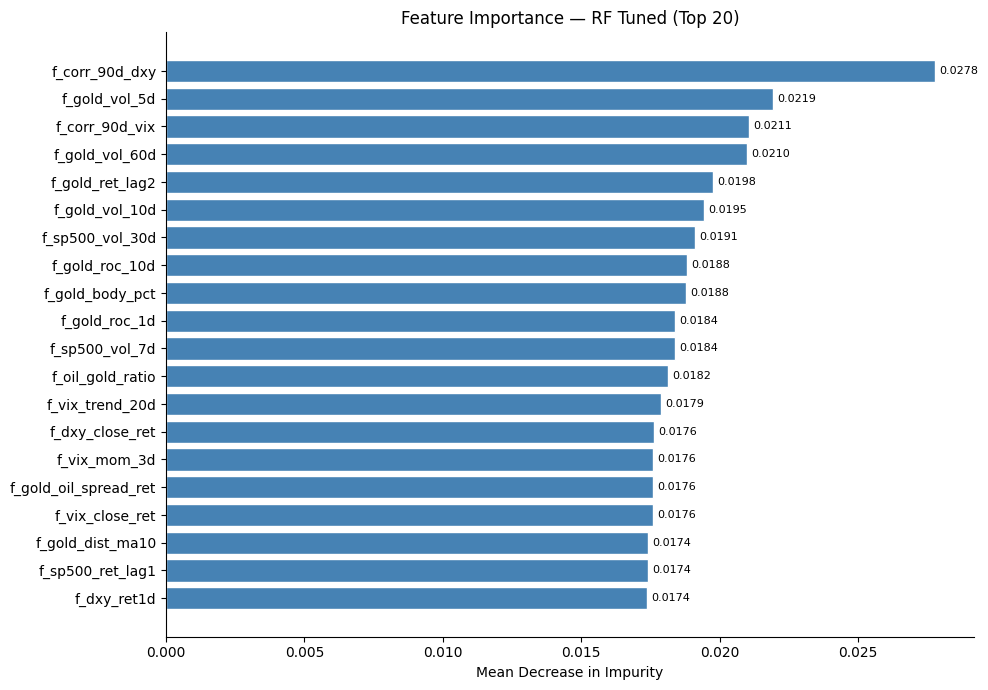

In [9]:
def plot_feature_importance(model, feature_names, title="Feature Importance", top_n=20):
    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1][:top_n]
    top_features = [feature_names[i] for i in indices]
    top_imp      = importances[indices]

    fig, ax = plt.subplots(figsize=(10, max(4, top_n * 0.35)))
    bars = ax.barh(top_features[::-1], top_imp[::-1], color='steelblue', edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    ax.set_xlabel("Mean Decrease in Impurity")
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({'Feature': top_features, 'Importance': top_imp})

print("\n>>> FEATURE IMPORTANCE — Baseline")
fi_base = plot_feature_importance(
    rf_clf, X_train.columns.tolist(),
    title="Feature Importance — RF Baseline (Top 20)"
)

print("\n>>> FEATURE IMPORTANCE — Tuned")
fi_tuned = plot_feature_importance(
    best_rf_clf, X_train.columns.tolist(),
    title="Feature Importance — RF Tuned (Top 20)"
)

# Visualization

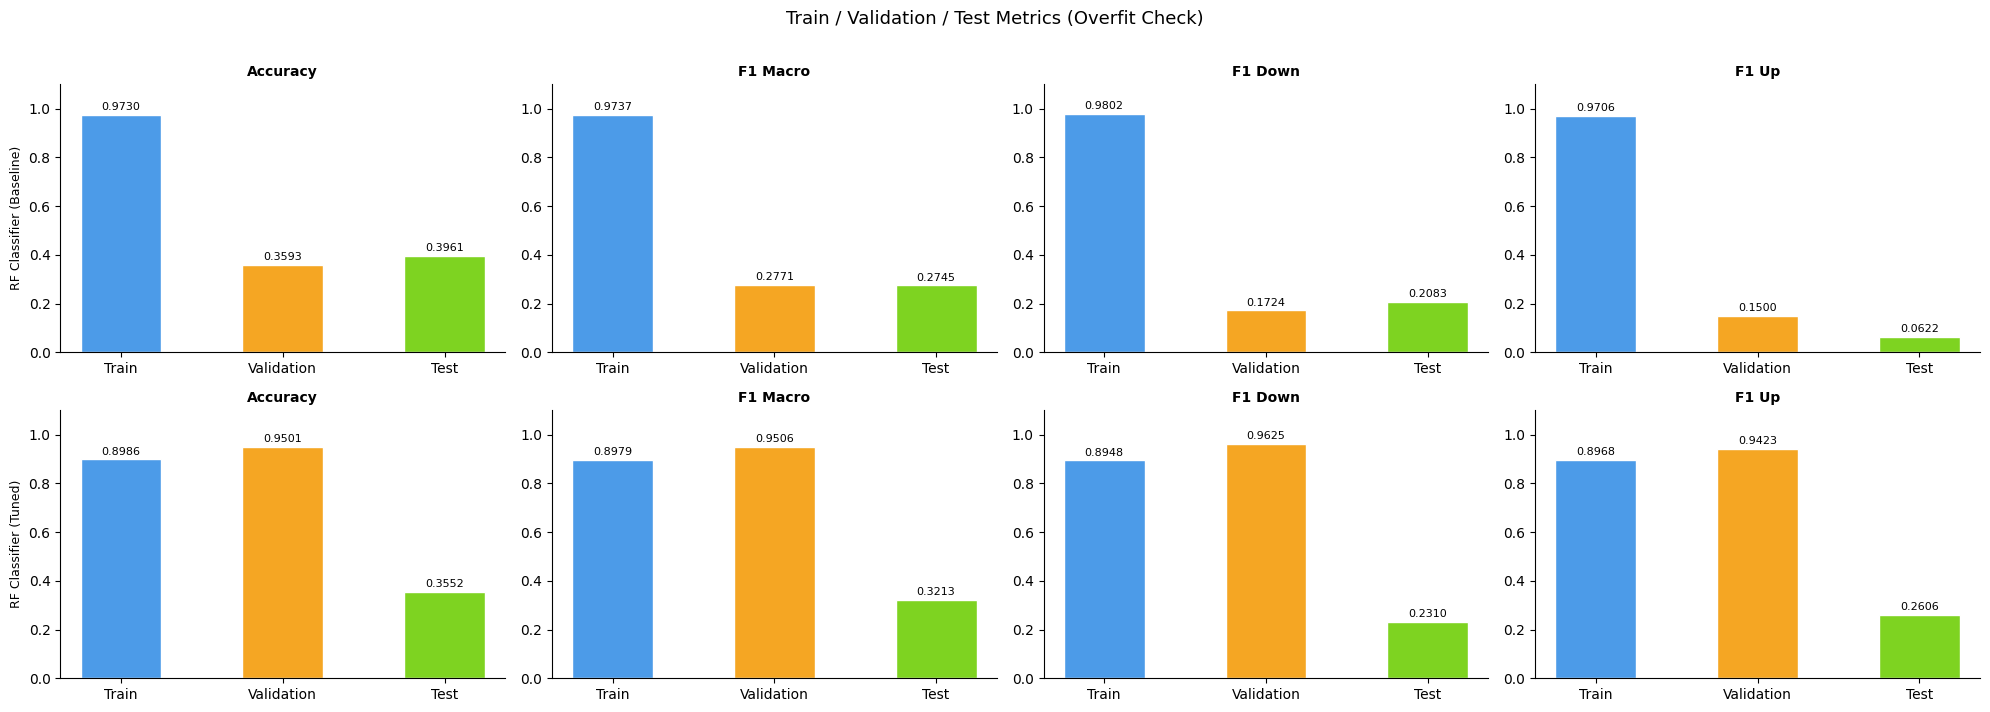

In [10]:
# Overfit gap + F1 per split
def plot_overfit_summary(results_df):
    models   = results_df['Model'].unique()
    metrics  = ['Accuracy', 'F1 Macro', 'F1 Down', 'F1 Up']
    splits   = ['Train', 'Validation', 'Test']
    colors   = {'Train': '#4C9BE8', 'Validation': '#F5A623', 'Test': '#7ED321'}

    fig, axes = plt.subplots(
        len(models), len(metrics),
        figsize=(5 * len(metrics), 3.5 * len(models)),
        sharey=False,
    )
    if len(models) == 1:
        axes = axes[np.newaxis, :]

    for row, model in enumerate(models):
        sub = results_df[results_df['Model'] == model]
        for col, metric in enumerate(metrics):
            ax = axes[row, col]
            vals  = [sub.loc[sub['Split'] == s, metric].values[0]
                     if s in sub['Split'].values else np.nan for s in splits]
            bars  = ax.bar(splits, vals,
                           color=[colors[s] for s in splits], width=0.5, edgecolor='white')
            ax.bar_label(bars, fmt='%.4f', fontsize=8, padding=2)
            ax.set_ylim(0, 1.1)
            ax.set_title(f"{metric}", fontsize=10, fontweight='bold')
            ax.spines[['top', 'right']].set_visible(False)
            if col == 0:
                ax.set_ylabel(model, fontsize=9)

    fig.suptitle("Train / Validation / Test Metrics (Overfit Check)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

plot_overfit_summary(all_results)

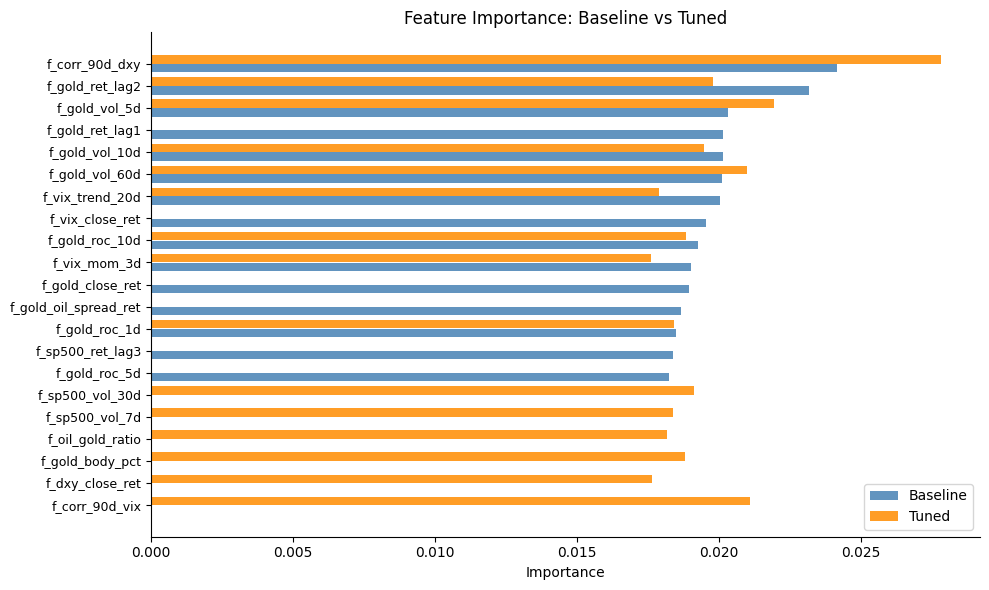

In [11]:
# Feature importance side-by-side
def plot_fi_comparison(fi_base, fi_tuned, top_n=15):
    common = pd.merge(
        fi_base.head(top_n).rename(columns={'Importance': 'Baseline'}),
        fi_tuned.head(top_n).rename(columns={'Importance': 'Tuned'}),
        on='Feature', how='outer',
    ).fillna(0).sort_values('Baseline', ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.4)))
    y = np.arange(len(common))
    ax.barh(y - 0.2, common['Baseline'], 0.38, label='Baseline', color='steelblue', alpha=0.85)
    ax.barh(y + 0.2, common['Tuned'],    0.38, label='Tuned',    color='darkorange', alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(common['Feature'], fontsize=9)
    ax.set_xlabel("Importance")
    ax.set_title("Feature Importance: Baseline vs Tuned")
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_fi_comparison(fi_base, fi_tuned)